<a href="https://colab.research.google.com/github/krlpopiel/SI_lab/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [ ]:
observations = 1000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(1000, 2)


In [ ]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


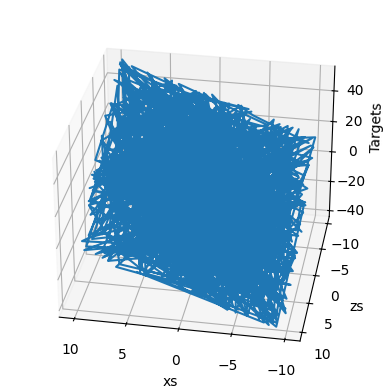

In [ ]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [ ]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[ 0.04931788]
 [-0.02508888]] [-0.01223604]


In [ ]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = targets - outputs

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights + eta * np.dot(inputs.T, deltas_scaled)
  biases = biases + eta * np.sum(deltas_scaled)

228.91361538419784
32.70657014771123
13.652549419505002
11.425390554075525
10.81743813166517
10.380146630097492
9.974291802207306
9.585870885691966
9.212954670847497
8.854807946070753
8.510834180252415
8.180471334550333
7.86318070883503
7.558445032034046
7.265767512986051
6.984671019455485
6.714697299105413
6.455406232309175
6.206375114638859
5.967197967757541
5.737484877580519
5.516861358625078
5.3049677435125435
5.101458596627224
4.906002150976446
4.71827976733359
4.537985414782443
4.3648251718159985
4.1985167471763924
4.03878901965486
3.8853815961014226
3.7380443869238156
3.5965371983835905
3.4606293410247635
3.330099253596607
3.204734141857576
3.084329631671448
2.968689435830199
2.8576250340604443
2.7509553656917816
2.648506534486003
2.5501115251459923
2.4556099310421606
2.3648476927125177
2.2776768467101105
2.1939552843883776
2.1135465202311696
2.036319469349785
1.9621482337842735
1.890911897260631
1.822494328069307
1.7567839897436361
1.6936737592296076
1.6330607522504939
1.574846

In [ ]:
print(weights, biases)

[[ 1.99427018]
 [-2.99922354]] [4.3111562]


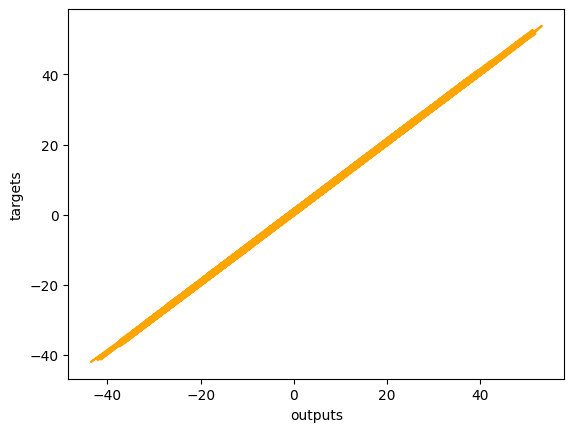

In [ ]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()